# Customer Segmentation and Review Score Prediction for Olist E-Commerce
### By Brad Wicklund

## 03. Pre-processing and Modeling

The goal of this project is to better understand customer behavior and satisfaction in the Olist Brazilian E-Commerce dataset using two complementary modeling approaches. First, I apply RFM analysis (Recency, Frequency, Monetary) combined with clustering methods to segment customers into meaningful groups. Both rule-based scoring and K-Means clustering reveal four key segments which provide a framework for targeted retention, reactivation, and loyalty strategies.  

Second, I build regression models to predict customer review scores using order, delivery, and payment features. After testing multiple approaches, Gradient Boosting performed best (R² ≈ 0.26), showing that review outcomes are most strongly driven by delivery-related factors such as delays, fulfillment status, and delivery speed. Together, these models highlight who Olist’s customers are and what drives their satisfaction, providing actionable insights for improving the customer experience and supporting long-term growth.

## A. Setup Notebook

In [267]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from datetime import datetime
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
# Load data
df = pd.read_csv('../data/processed/olist_orders_eda_clean.csv')

## B. Review Data and Final Cleaning

### i. Check Structure of Cleaned Data

In [7]:
df.head()

,order_status,approval_lag_days,ship_lag_days,delivery_time_days,delay_vs_est_days,items_n,order_price_sum,order_freight_sum,sellers_n,products_n,...,pay_credit_card_any,pay_debit_card_any,pay_voucher_any,review_score,review_creation_date,customer_unique_id,customer_city,customer_state,installment_bin,items_bin
0,delivered,0.007431,2.366493,8.436574,-7.107488,1.0,29.99,8.72,1.0,1.0,...,1.0,0.0,1.0,4.0,2017-10-11 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,1
1,delivered,1.279745,0.462882,13.782037,-5.355729,1.0,118.70,22.76,1.0,1.0,...,0.0,0.0,0.0,4.0,2018-08-08 00:00:00,af07308b275d755c9edb36a90c618231,barreiras,BA,1,1
2,delivered,0.011505,0.204595,9.394213,-17.245498,1.0,159.90,19.22,1.0,1.0,...,1.0,0.0,0.0,5.0,2018-08-18 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,2-3,1
3,delivered,0.012419,3.745833,13.208750,-12.980069,1.0,45.00,27.20,1.0,1.0,...,1.0,0.0,0.0,5.0,2017-12-03 00:00:00,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,1,1
4,delivered,0.042940,0.893113,2.873877,-9.238171,1.0,19.90,8.72,1.0,1.0,...,1.0,0.0,0.0,5.0,2018-02-17 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,1,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_status          99441 non-null  object 
 1   approval_lag_days     99281 non-null  float64
 2   ship_lag_days         97644 non-null  float64
 3   delivery_time_days    96476 non-null  float64
 4   delay_vs_est_days     96476 non-null  float64
 5   items_n               98666 non-null  float64
 6   order_price_sum       98666 non-null  float64
 7   order_freight_sum     98666 non-null  float64
 8   sellers_n             98666 non-null  float64
 9   products_n            98666 non-null  float64
 10  order_value           98666 non-null  float64
 11  total_payment_value   99440 non-null  float64
 12  max_installments      99440 non-null  float64
 13  pay_boleto_n          99440 non-null  float64
 14  pay_credit_card_n     99440 non-null  float64
 15  pay_debit_card_n   

### ii. Check for Missing Values

In [12]:
# Count of missing values per column
df.isnull().sum()

order_status               0
approval_lag_days        160
ship_lag_days           1797
delivery_time_days      2965
delay_vs_est_days       2965
items_n                  775
order_price_sum          775
order_freight_sum        775
sellers_n                775
products_n               775
order_value              775
total_payment_value        1
max_installments           1
pay_boleto_n               1
pay_credit_card_n          1
pay_debit_card_n           1
pay_voucher_n              1
payments_count             1
pay_boleto_any             1
pay_credit_card_any        1
pay_debit_card_any         1
pay_voucher_any            1
review_score             768
review_creation_date     768
customer_unique_id         0
customer_city              0
customer_state             0
installment_bin            3
items_bin                776
dtype: int64

In [14]:
# Percentage of missing values per column
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

delivery_time_days      2.981668
delay_vs_est_days       2.981668
ship_lag_days           1.807102
items_bin               0.780362
order_freight_sum       0.779357
order_value             0.779357
sellers_n               0.779357
products_n              0.779357
order_price_sum         0.779357
items_n                 0.779357
review_creation_date    0.772317
review_score            0.772317
approval_lag_days       0.160899
installment_bin         0.003017
pay_boleto_any          0.001006
pay_voucher_any         0.001006
pay_debit_card_any      0.001006
pay_credit_card_any     0.001006
pay_credit_card_n       0.001006
payments_count          0.001006
pay_voucher_n           0.001006
pay_debit_card_n        0.001006
pay_boleto_n            0.001006
max_installments        0.001006
total_payment_value     0.001006
customer_unique_id      0.000000
customer_city           0.000000
customer_state          0.000000
order_status            0.000000
dtype: float64

In [16]:
# Drop rows with missing review scores
df = df.dropna(subset=['review_score'])

In [18]:
# Drop rows with missing approval lag days
df = df.dropna(subset=['approval_lag_days'])

In [20]:
# Drop rows with missing items_n
df = df.dropna(subset=['items_n'])

In [22]:
# Drop rows with missing installment_bin
df = df.dropna(subset=['installment_bin'])

In [24]:
# Drop rows with missing items_bin
df = df.dropna(subset=['items_bin'])

In [26]:
# Add flag to rows with missing delivery data
for col in ['ship_lag_days', 'delivery_time_days', 'delay_vs_est_days']:
    df[col + '_missing'] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(df[col].median())

In [28]:
# Check again for missing values
df.isnull().sum()

order_status                  0
approval_lag_days             0
ship_lag_days                 0
delivery_time_days            0
delay_vs_est_days             0
items_n                       0
order_price_sum               0
order_freight_sum             0
sellers_n                     0
products_n                    0
order_value                   0
total_payment_value           0
max_installments              0
pay_boleto_n                  0
pay_credit_card_n             0
pay_debit_card_n              0
pay_voucher_n                 0
payments_count                0
pay_boleto_any                0
pay_credit_card_any           0
pay_debit_card_any            0
pay_voucher_any               0
review_score                  0
review_creation_date          0
customer_unique_id            0
customer_city                 0
customer_state                0
installment_bin               0
items_bin                     0
ship_lag_days_missing         0
delivery_time_days_missing    0
delay_vs

### iii. Drop Irrelevant Columns

In [31]:
# Drop customer_city
df = df.drop(columns=['customer_city'])

In [33]:
# Check if order_value is equal to order_price_sum + order_freight_sum
# Check if all values match
(df['order_value'] == (df['order_price_sum'] + df['order_freight_sum'])).all()

False

In [35]:
# Check for number of mismatches
mismatches = df[df['order_value'] != (df['order_price_sum'] + df['order_freight_sum'])]
print(len(mismatches))
mismatches.head()

10049


,order_status,approval_lag_days,ship_lag_days,delivery_time_days,delay_vs_est_days,items_n,order_price_sum,order_freight_sum,sellers_n,products_n,...,pay_voucher_any,review_score,review_creation_date,customer_unique_id,customer_state,installment_bin,items_bin,ship_lag_days_missing,delivery_time_days_missing,delay_vs_est_days_missing
17,delivered,0.006146,1.779664,12.954919,-20.057917,1.0,27.99,15.10,1.0,1.0,...,0.0,5.0,2018-01-09 00:00:00,6087cfc70fd833cf2db637a5e6e9d76b,SC,4-6,1,0,0,0
20,delivered,0.564340,17.573542,21.327963,11.933171,1.0,109.90,8.96,1.0,1.0,...,0.0,2.0,2017-10-01 00:00:00,d699688533772c15a061e8ce81cb56df,SP,1,1,0,0,0
24,delivered,0.652905,0.377882,4.277627,-3.233021,1.0,89.90,14.21,1.0,1.0,...,0.0,5.0,2018-08-14 00:00:00,9c9242ad7f1b52d926ea76778e1c0c57,SP,1,1,0,0,0
50,delivered,1.535278,3.680775,12.985880,-8.429178,1.0,39.47,13.37,1.0,1.0,...,0.0,5.0,2018-02-15 00:00:00,b2cac0b16835dabf811b204127f58afa,SP,1,1,0,0,0
60,delivered,1.200729,2.802581,4.935012,-12.146759,1.0,79.90,11.76,1.0,1.0,...,0.0,4.0,2017-12-15 00:00:00,6da92ae920ab16fc4eceb8fcd7bd43ce,SP,1,1,0,0,0


Order value does not perfectly align with order price sum + order freight sum so we will keep all three features.

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97899 entries, 0 to 99440
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_status                97899 non-null  object 
 1   approval_lag_days           97899 non-null  float64
 2   ship_lag_days               97899 non-null  float64
 3   delivery_time_days          97899 non-null  float64
 4   delay_vs_est_days           97899 non-null  float64
 5   items_n                     97899 non-null  float64
 6   order_price_sum             97899 non-null  float64
 7   order_freight_sum           97899 non-null  float64
 8   sellers_n                   97899 non-null  float64
 9   products_n                  97899 non-null  float64
 10  order_value                 97899 non-null  float64
 11  total_payment_value         97899 non-null  float64
 12  max_installments            97899 non-null  float64
 13  pay_boleto_n                97899 no

In [40]:
# Convert review_creation_date to datetime
# Keep a copy of the raw text just in case
df['review_creation_date_raw'] = df['review_creation_date']

# Convert to datetime
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'], format='mixed')

# Sanity check
df.review_creation_date.info()

<class 'pandas.core.series.Series'>
Index: 97899 entries, 0 to 99440
Series name: review_creation_date
Non-Null Count  Dtype         
--------------  -----         
97899 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.5 MB


## C. RFM Cluster Modeling

### i. Convert Datetime and Create RFM Features

In [44]:
# Convert to datetime
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'])

# Snapshot date = day after last review
snapshot_date = df['review_creation_date'].max() + pd.Timedelta(days=1)

# Aggregate RFM
rfm = df.groupby('customer_unique_id').agg({
    'review_creation_date': lambda x: (snapshot_date - x.max()).days,
    'review_score': 'count',                                         
    'total_payment_value': 'sum'                                     
}).reset_index()

# Rename columns
rfm.rename(columns={
    'review_creation_date': 'recency',
    'review_score': 'frequency',
    'total_payment_value': 'monetary'
}, inplace=True)

rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,107,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,113,1,27.19
2,0000f46a3911fa3c0805444483337064,513,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,303,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,277,1,196.89


In [45]:
# Check rfm info
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94704 entries, 0 to 94703
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  94704 non-null  object 
 1   recency             94704 non-null  int64  
 2   frequency           94704 non-null  int64  
 3   monetary            94704 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 2.9+ MB


In [46]:
# Check rfm describe
rfm.describe()

,recency,frequency,monetary
count,94704.000000,94704.000000,94704.000000
mean,228.049744,1.033737,165.782047
std,152.110648,0.210523,227.141591
min,1.000000,1.000000,9.590000
25%,107.000000,1.000000,63.100000
50%,207.000000,1.000000,107.850000
75%,338.000000,1.000000,182.910000
max,686.000000,16.000000,13664.080000


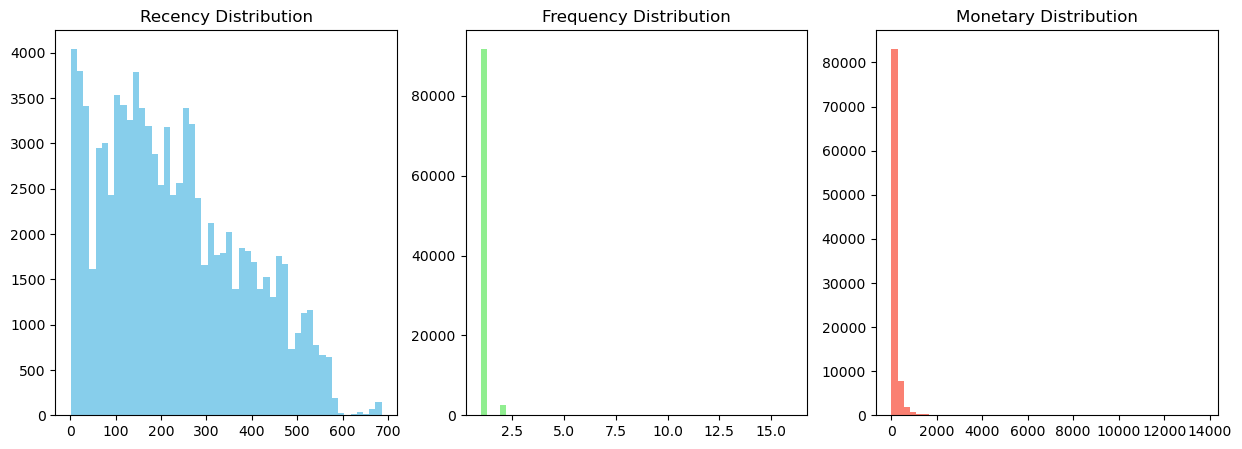

In [64]:
# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].hist(rfm['recency'], bins=50, color='skyblue')
axes[0].set_title('Recency Distribution')

axes[1].hist(rfm['frequency'], bins=50, color='lightgreen')
axes[1].set_title('Frequency Distribution')

axes[2].hist(rfm['monetary'], bins=50, color='salmon')
axes[2].set_title('Monetary Distribution')

plt.show()

### ii. Standardize Data Before Modeling

In [67]:
# Standardize rfm data prior to modeling
scaler = StandardScaler()

In [69]:
# Fit and transform features
rfm_features = rfm[['recency', 'frequency', 'monetary']]

rfm_scaled = scaler.fit_transform(rfm_features)

In [71]:
# Create scaled dataframe
rfm_scaled_A = pd.DataFrame(rfm_scaled, 
                              columns=['recency','frequency','monetary'],
                              index=rfm.index)

rfm_scaled_A.head()

,recency,frequency,monetary
0,-0.795805,-0.160253,-0.105142
1,-0.756360,-0.160253,-0.610160
2,1.873319,-0.160253,-0.350277
3,0.492738,-0.160253,-0.537826
4,0.321809,-0.160253,0.136955


In [73]:
# Sanity check
rfm_scaled_A.describe().round(2)

,recency,frequency,monetary
count,94704.00,94704.00,94704.00
mean,0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-1.49,-0.16,-0.69
25%,-0.80,-0.16,-0.45
50%,-0.14,-0.16,-0.26
75%,0.72,-0.16,0.08
max,3.01,71.09,59.43


In [89]:
# Creating second scaled set of data with log transform due to skewed data for comparison
rfm_log = rfm[['recency','frequency','monetary']].copy()
rfm_log['frequency'] = np.log1p(rfm_log['frequency'])
rfm_log['monetary']  = np.log1p(rfm_log['monetary'])

scaler = StandardScaler()
rfm_scaled_B = scaler.fit_transform(rfm_log)


rfm_scaled_B = pd.DataFrame(
    rfm_scaled_B, 
    columns=['recency','frequency','monetary'],
    index=rfm.index
)

In [91]:
# Sanity check
rfm_scaled_B.head()

,recency,frequency,monetary
0,-0.795805,-0.17101,0.285469
1,-0.756360,-0.17101,-1.718442
2,1.873319,-0.17101,-0.324047
3,0.492738,-0.17101,-1.151513
4,0.321809,-0.17101,0.687401


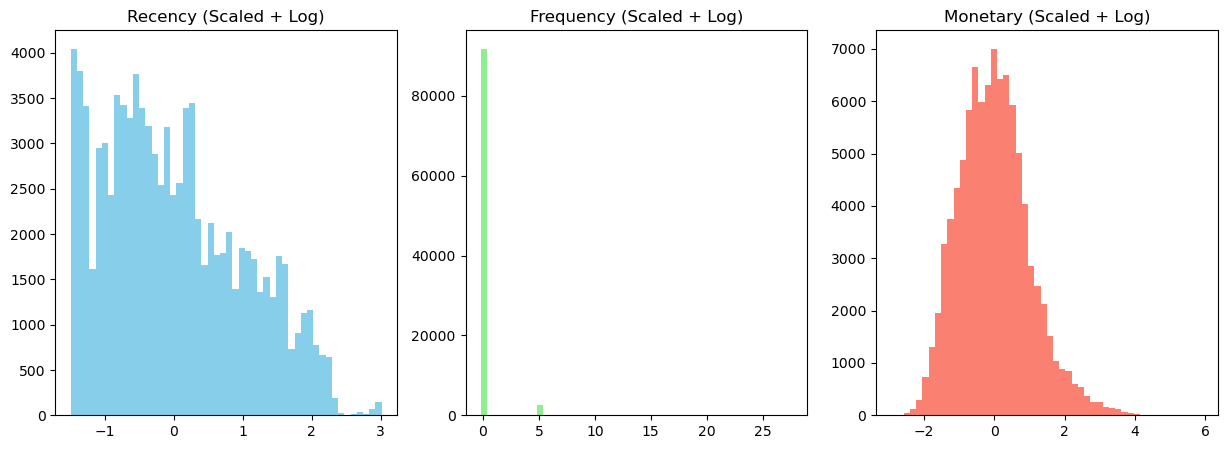

In [93]:
# Plot log scaled data to check distribution
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].hist(rfm_scaled_B_df['recency'], bins=50, color='skyblue')
axes[0].set_title('Recency (Scaled + Log)')

axes[1].hist(rfm_scaled_B_df['frequency'], bins=50, color='lightgreen')
axes[1].set_title('Frequency (Scaled + Log)')

axes[2].hist(rfm_scaled_B_df['monetary'], bins=50, color='salmon')
axes[2].set_title('Monetary (Scaled + Log)')

plt.show()

### iii. K-Means Clustering 

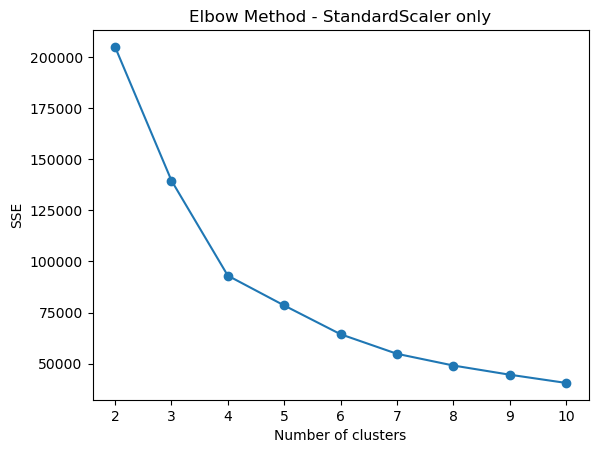

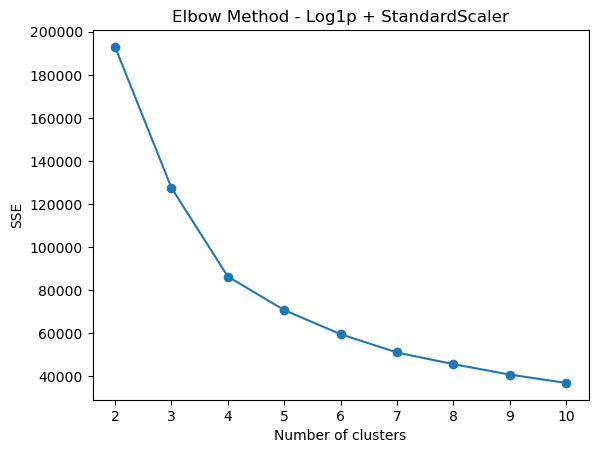

In [104]:
# Create function and complete elbow test on both sets of scaled data
def elbow_plot(data, title):
    sse = []
    for k in range(2,11):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        sse.append(kmeans.inertia_)
    
    plt.plot(range(2,11), sse, marker='o')
    plt.title(f'Elbow Method - {title}')
    plt.xlabel('Number of clusters')
    plt.ylabel('SSE')
    plt.show()

# Run elbow method for both versions
elbow_plot(rfm_scaled_A, "StandardScaler only")
elbow_plot(rfm_scaled_B, "Log1p + StandardScaler")

In [106]:
# Confirm k value choice of 4 using silhouette scores
for k in range(2,7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled_B)
    score = silhouette_score(rfm_scaled_B, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.707
k=3, silhouette=0.365
k=4, silhouette=0.373
k=5, silhouette=0.359
k=6, silhouette=0.347


In [112]:
# Fit final model
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled_B)

# Overall and per-cluster silhouette
labels = rfm['cluster'].values
overall_sil = silhouette_score(rfm_scaled_B, labels)
per_sample_sil = silhouette_samples(rfm_scaled_B, labels)
rfm['silhouette'] = per_sample_sil
print(f"Overall silhouette (k={k}): {overall_sil:.3f}")

# Profile clusters
profile = (
    rfm.groupby('cluster')
       .agg(n_customers=('customer_unique_id','count'),
            recency=('recency','mean'),
            frequency=('frequency','mean'),
            monetary=('monetary','mean'),
            sil_mean=('silhouette','mean'))
       .sort_values('monetary', ascending=False)
)
profile

Overall silhouette (k=4): 0.373


,n_customers,recency,frequency,monetary,sil_mean
cluster,,,,,
0,28103,163.197523,1.000000,320.699013,0.310430
3,2868,211.016736,2.114017,310.039554,0.648098
1,27148,417.513408,1.000000,119.465852,0.366011
2,36585,138.609621,1.000000,69.841908,0.405153


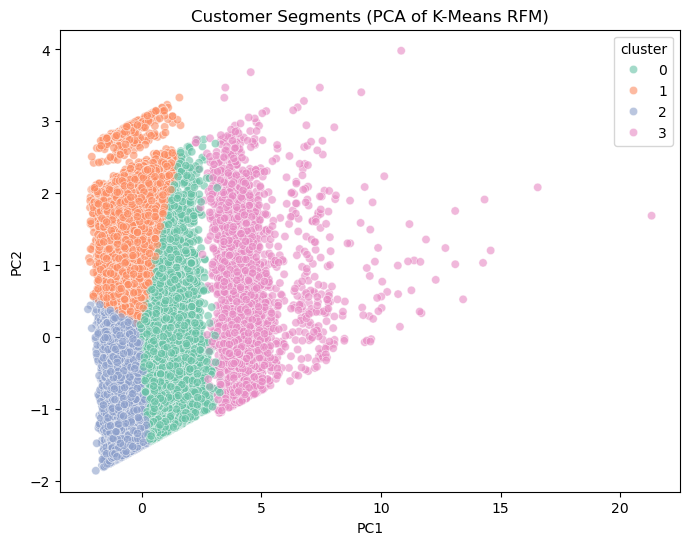

In [166]:
# Reduce to 2 dimensions with PCA
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled_B)

# Create dataframe with cluster labels
rfm_pca_df = pd.DataFrame(rfm_pca, columns=['PC1','PC2'])
rfm_pca_df['cluster'] = rfm['cluster']

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', 
                palette='Set2', data=rfm_pca_df, alpha=0.6)
plt.title('Customer Segments (PCA of K-Means RFM)')
plt.show()

### iv. Rule Based RFM Clustering

In [135]:
# Create RFM scores
# R score
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])

# F score
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# M score
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])

In [137]:
# Bulid RFM score string
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [139]:
# Map to segments

def segment_4groups(rfm_score):
    # Champions
    if re.match(r'[4-5][4-5][4-5]', rfm_score):
        return 'Champions'
    
    # Loyal
    elif re.match(r'[3-5][2-5][2-5]', rfm_score):
        return 'Loyal'
    
    # At Risk
    elif re.match(r'[1-2][3-5][3-5]', rfm_score):
        return 'At Risk'
    
    # Lost
    else:
        return 'Lost'

rfm['segment'] = rfm['RFM_score'].apply(segment_4groups)

In [141]:
# Profile to segments
rfm.groupby('segment').agg({
    'recency':'mean',
    'frequency':'mean',
    'monetary':['mean','count']
}).round(1)

recency frequency monetary       
             mean      mean     mean  count
segment                                    
At Risk     384.7       1.1    244.5  13240
Champions    82.2       1.2    315.5   6638
Lost        267.2       1.0    115.3  44734
Loyal       133.1       1.0    173.2  30092

### v. Compare K-Means to Rule-based RFM

In [152]:
# K-Means clusters
km_counts = rfm['cluster'].value_counts().sort_index()

# Rule-based segments (4-group)
rule_counts = rfm['segment'].value_counts()

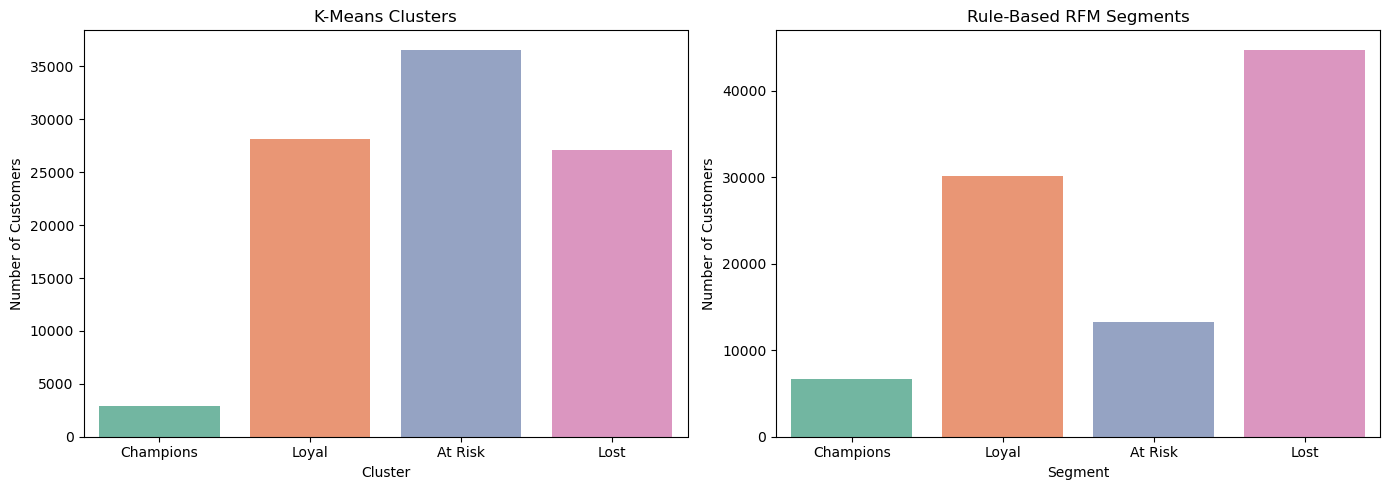

In [158]:
# Recount using cluster names
km_counts_named = rfm['cluster_name'].value_counts().reindex(["Champions","Loyal","At Risk","Lost"])

# Recount rule-based segments
rule_counts_named = rfm['segment'].value_counts().reindex(["Champions","Loyal","At Risk","Lost"])

# Plot K-Means and Rule-based RFM
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# K-Means clusters
sns.barplot(x=km_counts_named.index, y=km_counts_named.values, 
            hue=km_counts_named.index, ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Number of Customers")

# Rule-based segments
sns.barplot(x=rule_counts_named.index, y=rule_counts_named.values, 
            hue=rule_counts_named.index, ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Rule-Based RFM Segments")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

#### Clustering Takeaways

1. **Model Performance**
   - RFM features (Recency, Frequency, Monetary) were scaled and clustered using K-Means.
   - The elbow method and silhouette analysis supported a 4 cluster solution.
   - Clusters were stable and interpretable, with strong separation driven by recency and monetary value.
<br>
<br>
2. **Key Customer Segments**
   - **Champions**: Loyal, high-value repeat buyers with low recency, high frequency, and high monetary value.
   - **Loyal**: Recent, big-ticket one-time buyers who purchase less frequently but spend significantly.
   - **At Risk**: Recent but low-spend customers with limited purchase frequency.
   - **Lost**: Customers with very old purchases, low frequency, and low monetary value.
<br>
<br>
3. **Comparison of Methods**
   - **K-Means**: More data-driven, optimized cluster boundaries, highlighted subtle patterns such as “big-ticket one-time buyers.”  
   - **Rule-Based RFM**: Simpler, easier for business stakeholders to interpret, but less flexible (forced equal sized bins).  
   - Both approaches consistently identified the same high level groups (Champions, Loyal, At Risk, Lost), which increases confidence in the segmentation.
<br>
<br>
4. **Business Implications**
   - Retention opportunity: The majority of customers fall into Lost or At Risk, highlighting the need for re-engagement campaigns.
   - Protect Champions: Though small in size, Champions are critical to revenue; reward programs or loyalty benefits could maintain their engagement.
   - Upsell Loyal buyers: These customers spend a lot but purchase infrequently; targeted campaigns could encourage repeat behavior.
   - Overall, segmentation highlights that customer retention and reactivation represent the largest growth opportunity for Olist.

## D. Regression Modeling

### i. Fork and Setup Data for Regression Modeling

In [192]:
# Fork data for regression
data = df.copy()

# Drop identifiers and raw dates
drop_cols = ['customer_city', 'review_creation_date', 'customer_unique_id', 'review_creation_date_raw']
drop_cols = [c for c in drop_cols if c in data.columns]
data = data.drop(columns=drop_cols)

# Separate target and features
TARGET = 'review_score'
y = data[TARGET].astype(float)
X = data.drop(columns=[TARGET])

# Separate categorical features to one hot encode
cat_cols = [c for c in ['order_status', 'installment_bin', 'items_bin', 'customer_state'] if c in X.columns]

num_cols = [c for c in X.columns if c not in cat_cols]
print(f"Categorical: {cat_cols}\nNumeric: {len(num_cols)} cols")

Categorical: ['order_status', 'installment_bin', 'items_bin', 'customer_state']
Numeric: 24 cols


In [194]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97899 entries, 0 to 99440
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_status                97899 non-null  object 
 1   approval_lag_days           97899 non-null  float64
 2   ship_lag_days               97899 non-null  float64
 3   delivery_time_days          97899 non-null  float64
 4   delay_vs_est_days           97899 non-null  float64
 5   items_n                     97899 non-null  float64
 6   order_price_sum             97899 non-null  float64
 7   order_freight_sum           97899 non-null  float64
 8   sellers_n                   97899 non-null  float64
 9   products_n                  97899 non-null  float64
 10  order_value                 97899 non-null  float64
 11  total_payment_value         97899 non-null  float64
 12  max_installments            97899 non-null  float64
 13  pay_boleto_n                97899 no

### ii. Train / Test Split

In [196]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### iii. Preprocessing Pipeline

In [199]:
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols),
    ],
    remainder='drop'
)

### iv. Create Evaluator Function

In [219]:
try:
    from sklearn.metrics import root_mean_squared_error as rmse_fn
    def rmse(y_true, y_pred):
        return rmse_fn(y_true, y_pred)
except ImportError:
    # compatibility with older sklearn
    def rmse(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

def evaluate(model, X_tr=X_train, X_te=X_test, y_tr=y_train, y_te=y_test, name="Model"):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse_val = rmse(y_te, preds)
    mae_val  = mean_absolute_error(y_te, preds)
    r2_val   = r2_score(y_te, preds)
    print(f"{name}:  RMSE={rmse_val:.3f}  MAE={mae_val:.3f}  R²={r2_val:.3f}")
    return rmse_val, mae_val, r2_val

### v. Compare Baseline with Evaluation of Common Regression Models

In [222]:
# Baseline
baseline = Pipeline(steps=[
    ('prep', preprocess),
    ('model', DummyRegressor(strategy='mean'))
])
evaluate(baseline, name="Baseline (Mean)")

# Linear Regression
linreg = Pipeline(steps=[
    ('prep', preprocess),
    ('model', LinearRegression())
])
evaluate(linreg, name="Linear Regression")

# Random Forest
rf = Pipeline(steps=[
    ('prep', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ))
])
evaluate(rf, name="Random Forest")

# Gradient Boosting
gbr = Pipeline(steps=[
    ('prep', preprocess),
    ('model', GradientBoostingRegressor(random_state=42))
])
evaluate(gbr, name="Gradient Boosting")

Baseline (Mean):  RMSE=1.324  MAE=1.035  R²=-0.000
Linear Regression:  RMSE=1.184  MAE=0.911  R²=0.200
Random Forest:  RMSE=1.159  MAE=0.893  R²=0.234
Gradient Boosting:  RMSE=1.139  MAE=0.873  R²=0.260


(1.1391515105147476, 0.8733824881409962, 0.25976410741769307)

### vi. Extract Top Features

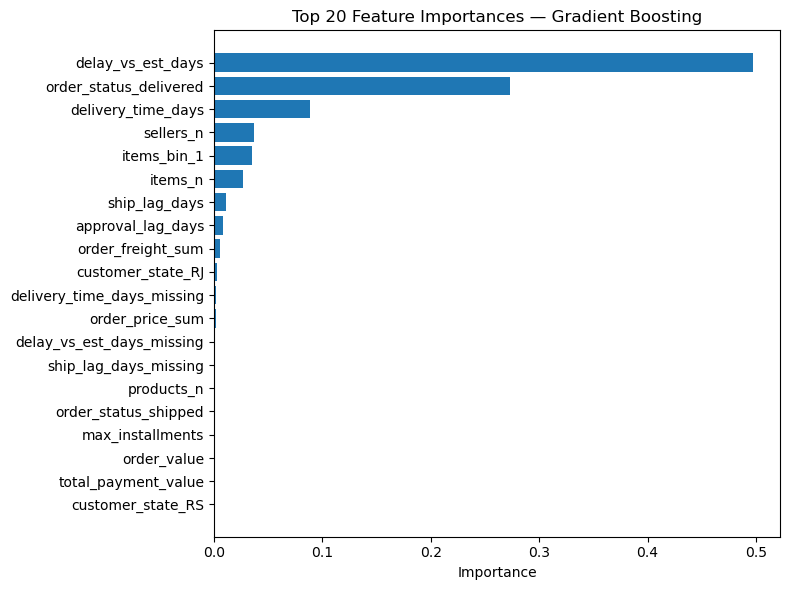

In [240]:
# Grab preprocessing step from pipeline
prep = gbr.named_steps['prep']

# Categorical feature names after OHE
cat_cols_used = prep.transformers_[0][2]
ohe = prep.named_transformers_['cat']
if len(cat_cols_used):
    cat_feature_names = ohe.get_feature_names_out(cat_cols_used)
else:
    cat_feature_names = np.array([])

# Numeric feature names
num_cols_used = prep.transformers_[1][2]
num_feature_names = np.array(num_cols_used)

# Full feature name list in the order seen by the model
feature_names = np.concatenate([cat_feature_names, num_feature_names])

# Get importances from the model
gb = gbr.named_steps['model']
importances = gb.feature_importances_

# Put into a DataFrame and sort
fi = (pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False)
        .reset_index(drop=True))

# Display top N
N = 20
topN = fi.head(N)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(topN['feature'][::-1], topN['importance'][::-1])
plt.xlabel("Importance")
plt.title(f"Top {N} Feature Importances — Gradient Boosting")
plt.tight_layout()
plt.show()

#### Regression Modeling Takeaways

1. **Model Performance**
   - Best performing model: **Gradient Boosting** with **R² ≈ 0.26** (explains 26% of variance in review scores).
   - Errors: **RMSE ≈ 1.14**, **MAE ≈ 0.87** Predictions are typically within 1 star.
   - This magnitude is expected for subjective, noisy review data and is a clear lift over the baseline (R² ≈ 0).
<br>
<br>
2. **Key Drivers of Review Scores**
   - Delivery delays (`delay_vs_est_days`) are the strongest predictor by far; more delay lead to lower reviews.
   - Order status (delivered vs not) is the next most important; undelivered/canceled orders depress scores.
   - Overall delivery time (`delivery_time_days`) also matters; faster fulfillment leads to better reviews.
   - Price/payment details have relatively minor impact compared to logistics factors.
<br>
<br>
3. **Business Implications**
   - Prioritize on-time delivery and delay reduction to improve satisfaction.
   - Ensure order completion (reduce cancellations/failed deliveries).
   - Streamline large orders to lower friction and complaints.
   - Focus optimization on logistics reliability rather than payment structure this has the biggest ROI for review improvement.

## E. Conclusions

### Joint Conclusion: Customer Segmentation and Review Prediction

1. **Segmentation Insights**
   - Both K-Means clustering and rule-based RFM segmentation consistently revealed four core customer groups: **Champions, Loyal, At Risk, and Lost**.  
   - The majority of customers fall into Lost or At Risk, showing limited recent engagement and low monetary value.  
   - A small but highly valuable Champion group drives a disproportionate share of revenue, while Loyal customers represent an opportunity to convert big-ticket one-time buyers into repeat purchasers.
<br>
<br>
2. **Review Prediction Insights**
   - The best-performing regression model, Gradient Boosting, explained ~26% of the variance in review scores (RMSE ≈ 1.14, MAE ≈ 0.87).  
   - Delivery delays were the most important predictor of reviews, followed by order completion status (delivered vs not) and overall delivery speed.  
<br>
<br>
3. **Integrated Business Implications**
   - Retention and reactivation should be Olist’s top priority: most customers churn after one order, and regression confirms that delivery experience is the key driver of satisfaction.  
   - Olist should protect Champions these customers already demonstrate loyalty and high value. Prioritize them with reliable logistics, loyalty benefits, and personalized outreach.  
   - We should upsell Loyal one-time big spenders these customers show high monetary value but low frequency. Improving their delivery experience and targeting with repeat-purchase campaigns could unlock growth.  
   - Addressing logistics reliability at scale across all customer groups, reducing delays and ensuring successful deliveries are the most powerful levers for improving reviews, increasing retention, and growing lifetime value.
<br>
<br>
4. **Conclusion**
   - Overall, segmentation tells us who the customers are, while regression shows what drives their satisfaction. Together, these analyses highlight that Olist’s growth opportunity lies in fixing logistics performance and re-engaging inactive customers, while protecting and nurturing its small but valuable Champion segment.
<br>
<br>